# Loan Risk Analysis

End-to-end binary classification pipeline to predict whether a loan applicant is **high-risk (P3/P4)** or **low-risk (P1/P2)** using internal bank data and external CIBIL data.

## 1. Importing Libraries

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report, accuracy_score, r2_score,roc_auc_score

## 2. Loading Data

Two datasets are loaded:
- **External CIBIL data** — credit bureau information (credit score, delinquencies, enquiries)
- **Internal bank data** — applicant demographics and banking history

In [2]:
os.chdir('//Users//admin//Desktop//Internship//P1 - Loan_risk_Analysis')
ext_df=pd.read_csv('EXTERNAL_CIBIL_DATA - case_study2.csv')
int_df = pd.read_csv('INTERNAL_BANK_DATA - case_study1.csv')

### Preview: External CIBIL Data

In [3]:
ext_df.head()

,PROSPECTID,time_since_recent_payment,time_since_first_deliquency,time_since_recent_deliquency,num_times_delinquent,max_delinquency_level,max_recent_level_of_deliq,num_deliq_6mts,num_deliq_12mts,num_deliq_6_12mts,...,pct_CC_enq_L6m_of_L12m,pct_PL_enq_L6m_of_ever,pct_CC_enq_L6m_of_ever,max_unsec_exposure_inPct,HL_Flag,GL_Flag,last_prod_enq2,first_prod_enq2,Credit_Score,Approved_Flag
0,1,549,35,15,11,29,29,0,0,0,...,0.0,0.0,0.0,13.333,1,0,PL,PL,696,P2
1,2,47,-99999,-99999,0,-99999,0,0,0,0,...,0.0,0.0,0.0,0.860,0,0,ConsumerLoan,ConsumerLoan,685,P2
2,3,302,11,3,9,25,25,1,9,8,...,0.0,0.0,0.0,5741.667,1,0,ConsumerLoan,others,693,P2
3,4,-99999,-99999,-99999,0,-99999,0,0,0,0,...,0.0,0.0,0.0,9.900,0,0,others,others,673,P2
4,5,583,-99999,-99999,0,-99999,0,0,0,0,...,0.0,0.0,0.0,-99999.000,0,0,AL,AL,753,P1


### Preview: Internal Bank Data

In [4]:
int_df.head()

,PROSPECTID,Total_TL,Tot_Closed_TL,Tot_Active_TL,Total_TL_opened_L6M,Tot_TL_closed_L6M,pct_tl_open_L6M,pct_tl_closed_L6M,pct_active_tl,pct_closed_tl,...,CC_TL,Consumer_TL,Gold_TL,Home_TL,PL_TL,Secured_TL,Unsecured_TL,Other_TL,Age_Oldest_TL,Age_Newest_TL
0,1,5,4,1,0,0,0.000,0.0,0.200,0.800,...,0,0,1,0,4,1,4,0,72,18
1,2,1,0,1,0,0,0.000,0.0,1.000,0.000,...,0,1,0,0,0,0,1,0,7,7
2,3,8,0,8,1,0,0.125,0.0,1.000,0.000,...,0,6,1,0,0,2,6,0,47,2
3,4,1,0,1,1,0,1.000,0.0,1.000,0.000,...,0,0,0,0,0,0,1,1,5,5
4,5,3,2,1,0,0,0.000,0.0,0.333,0.667,...,0,0,0,0,0,3,0,2,131,32


### Shape Check

In [5]:
ext_df.shape

(51336, 62)

In [6]:
int_df.shape

(51336, 26)

> **Observation:** Both datasets share `PROSPECTID` as the common key and will be merged on it. The external dataset has credit bureau features while the internal dataset has demographic and income features.

### Data Types and Null Info

In [7]:
ext_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51336 entries, 0 to 51335
Data columns (total 62 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   PROSPECTID                    51336 non-null  int64  
 1   time_since_recent_payment     51336 non-null  int64  
 2   time_since_first_deliquency   51336 non-null  int64  
 3   time_since_recent_deliquency  51336 non-null  int64  
 4   num_times_delinquent          51336 non-null  int64  
 5   max_delinquency_level         51336 non-null  int64  
 6   max_recent_level_of_deliq     51336 non-null  int64  
 7   num_deliq_6mts                51336 non-null  int64  
 8   num_deliq_12mts               51336 non-null  int64  
 9   num_deliq_6_12mts             51336 non-null  int64  
 10  max_deliq_6mts                51336 non-null  int64  
 11  max_deliq_12mts               51336 non-null  int64  
 12  num_times_30p_dpd             51336 non-null  int64  
 13  n

In [8]:
int_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51336 entries, 0 to 51335
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   PROSPECTID            51336 non-null  int64  
 1   Total_TL              51336 non-null  int64  
 2   Tot_Closed_TL         51336 non-null  int64  
 3   Tot_Active_TL         51336 non-null  int64  
 4   Total_TL_opened_L6M   51336 non-null  int64  
 5   Tot_TL_closed_L6M     51336 non-null  int64  
 6   pct_tl_open_L6M       51336 non-null  float64
 7   pct_tl_closed_L6M     51336 non-null  float64
 8   pct_active_tl         51336 non-null  float64
 9   pct_closed_tl         51336 non-null  float64
 10  Total_TL_opened_L12M  51336 non-null  int64  
 11  Tot_TL_closed_L12M    51336 non-null  int64  
 12  pct_tl_open_L12M      51336 non-null  float64
 13  pct_tl_closed_L12M    51336 non-null  float64
 14  Tot_Missed_Pmnt       51336 non-null  int64  
 15  Auto_TL            

> **Observation:** Several numeric columns contain `-99999` as a sentinel value — a placeholder used when data was unavailable at collection time. These must be identified and treated before any analysis or modelling.

## 3. Merging Datasets

An **inner join** on `PROSPECTID` ensures we only retain applicants present in both datasets.

In [9]:
# Merge 2 datasets

df= pd.merge(left = ext_df, right = int_df, on = 'PROSPECTID', how = 'inner')

In [10]:
df.shape

(51336, 87)

> **Observation:** The merged dataset shape confirms the number of applicants with records in both sources. Any reduction in rows compared to the original files is due to applicants missing from one of the two datasets.

### Statistical Summary

In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
PROSPECTID,51336.0,25668.500000,14819.571046,1.0,12834.75,25668.5,38502.25,51336.0
time_since_recent_payment,51336.0,-8129.961314,27749.328514,-99999.0,46.00,70.0,161.00,6065.0
time_since_first_deliquency,51336.0,-70020.091320,45823.312757,-99999.0,-99999.00,-99999.0,8.00,35.0
time_since_recent_deliquency,51336.0,-70022.375838,45819.820741,-99999.0,-99999.00,-99999.0,3.00,35.0
num_times_delinquent,51336.0,1.573749,4.165012,0.0,0.00,0.0,1.00,74.0
...,...,...,...,...,...,...,...,...
Secured_TL,51336.0,2.844904,6.187177,0.0,0.00,1.0,3.00,235.0
Unsecured_TL,51336.0,2.013694,3.198322,0.0,0.00,1.0,2.00,55.0
Other_TL,51336.0,1.089762,2.417496,0.0,0.00,0.0,1.00,80.0
Age_Oldest_TL,51336.0,-32.575639,2791.869609,-99999.0,14.00,33.0,64.00,392.0


> **Observation:** Extreme minimum values (e.g. `-99999`) are visible across several columns, confirming the presence of sentinel values. Columns like `Credit_Score`, `NETMONTHLYINCOME`, and enquiry counts show wide ranges, indicating diverse applicant profiles in the dataset.

## 4. Data Cleaning

### Step 1: Identifying Sentinel Values (-99999)

Columns containing `-99999` are identified and the percentage of corrupt values is calculated to decide the appropriate treatment strategy for each column.

In [12]:
# Find the columns with -99999 values

sentinel = (df == -99999).sum()
print(((sentinel[sentinel > 0]/len(df))*100).sort_values(ascending=False))

CC_utilization                  92.792582
PL_utilization                  86.557192
time_since_recent_deliquency    70.026882
max_delinquency_level           70.026882
time_since_first_deliquency     70.026882
max_unsec_exposure_inPct        45.149603
max_deliq_6mts                  25.109085
max_deliq_12mts                 21.100203
time_since_recent_enq           12.312997
enq_L3m                         12.312997
enq_L6m                         12.312997
enq_L12m                        12.312997
PL_enq_L6m                      12.312997
PL_enq_L12m                     12.312997
PL_enq                          12.312997
CC_enq_L6m                      12.312997
CC_enq                          12.312997
tot_enq                         12.312997
CC_enq_L12m                     12.312997
time_since_recent_payment        8.358657
pct_currentBal_all_TL            0.140252
Age_Oldest_TL                    0.077918
Age_Newest_TL                    0.077918
dtype: float64


> **Observation:** Columns like `CC_utilization`, `PL_utilization`, `time_since_recent_deliquency`, `max_delinquency_level`, `time_since_first_deliquency`, and `max_unsec_exposure_inPct` have **more than 40% sentinel values** — too sparse to impute reliably. These will be dropped. Remaining columns with lower proportions will be imputed using the median.

### Steps 2–5: Replace Sentinels, Drop Sparse Columns, Impute, Verify

In [13]:
# ── Step 1: Replace ALL sentinel values with NaN FIRST ────────────────────
df.replace(-99999, np.nan, inplace=True)

# ── Step 2: Drop columns with >40% sentinel ────────────────────────────────
# These are too sparse — over 40% of values were fake, not usable

col_to_drop = ['CC_utilization','PL_utilization','time_since_recent_deliquency','max_delinquency_level','time_since_first_deliquency','max_unsec_exposure_inPct']
df.drop(columns = col_to_drop,inplace = True, axis = 1)
print(f'Dropped {len(col_to_drop)} columns, New Shape: {df.shape}')


# ── Step 3: Fill delinquency recency columns with 0 ───────────────────────
# Missing here means no delinquency event occurred in that period
cols_fill_zero = ['max_deliq_6mts', 'max_deliq_12mts']
df[cols_fill_zero] = df[cols_fill_zero].fillna(0)


# ── Step 4: Fill enquiry & time columns with median ───────────────────────
# Missing = unknown history, median is the safest central estimate
col_to_impute = [
    'max_deliq_6mts','max_deliq_12mts','time_since_recent_enq','enq_L3m',
    'enq_L6m','enq_L12m','PL_enq_L6m','PL_enq_L12m','PL_enq','CC_enq_L6m',
    'CC_enq','tot_enq','CC_enq_L12m','time_since_recent_payment','Age_Oldest_TL','Age_Newest_TL','pct_currentBal_all_TL'
]
imputer = SimpleImputer(strategy='median')
df[col_to_impute] = imputer.fit_transform(df[col_to_impute])


# ── Step 5: Verify no sentinel values remain ──────────────────────────────
remaining = (df == -99999).sum().sum()
remaining_nulls = df.isnull().sum().sum()
print(f"Remaining -99999 values : {remaining}")
print(f"Remaining NaN values    : {remaining_nulls}")


Dropped 6 columns, New Shape: (51336, 81)
Remaining -99999 values : 0
Remaining NaN values    : 0


> **Observation:** After cleaning:
> - 6 highly sparse columns are dropped
> - Delinquency columns (`max_deliq_6mts`, `max_deliq_12mts`) are filled with 0 — missing means no event occurred
> - Remaining enquiry and time-based columns are filled with their median
> - Final check confirms 0 sentinel values and 0 null values — the dataset is clean and ready for EDA.

## 5. Exploratory Data Analysis (EDA)

### Target Variable Distribution

The target `Approved_Flag` has 4 classes: P1 (lowest risk) to P4 (highest risk). We check the class balance before binarizing.

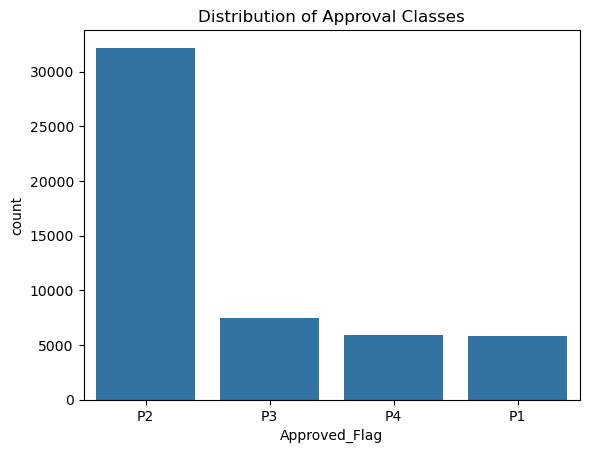

In [14]:
# Target Distribution
sns.countplot(data=df, x='Approved_Flag', order=df['Approved_Flag'].value_counts().index)
plt.title('Distribution of Approval Classes')
plt.show()


> **Observation:** The dataset is skewed towards low-risk applicants (P1/P2), which is typical in real lending data. We binarize the target as: **P1/P2 → 0 (low risk)**, **P3/P4 → 1 (high risk)**. This imbalance should be kept in mind when interpreting accuracy — AUC-ROC is a better metric here.

### Correlation Heatmap

Checking for multicollinearity among numeric features. Highly correlated features can cause instability in Logistic Regression coefficients.

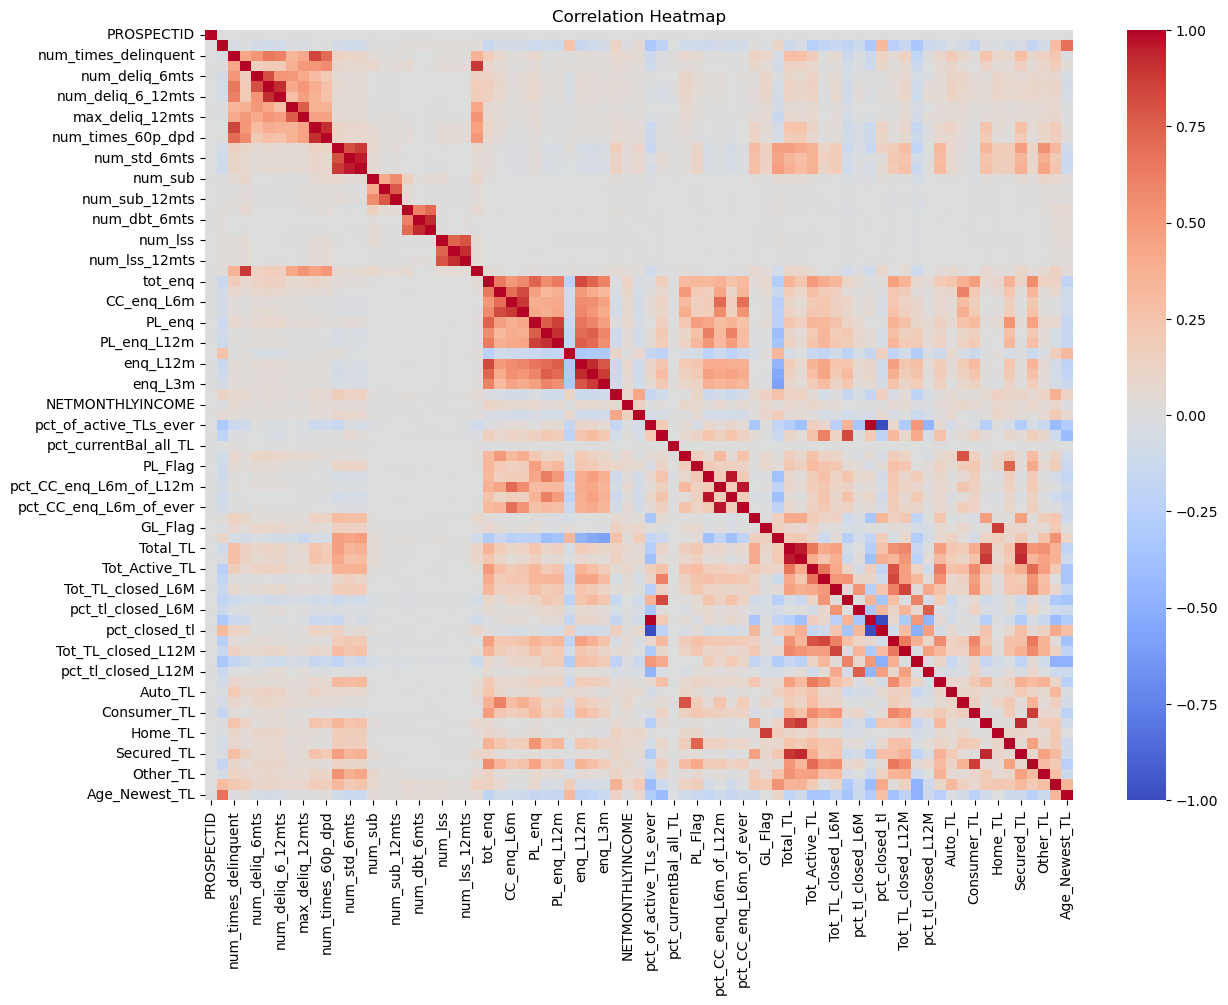

In [15]:
#Correlation check

num_df=df.select_dtypes('number')

plt.figure(figsize=(14, 10))
sns.heatmap(num_df.corr(), cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

In [16]:
corr = num_df.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

high_corr = upper.stack().sort_values(ascending=False)
high_corr[high_corr > 0.7]

pct_active_tl               pct_closed_tl             1.000000
pct_of_active_TLs_ever      pct_closed_tl             1.000000
                            pct_active_tl             1.000000
pct_PL_enq_L6m_of_L12m      pct_PL_enq_L6m_of_ever    0.965067
pct_CC_enq_L6m_of_L12m      pct_CC_enq_L6m_of_ever    0.962371
num_std_6mts                num_std_12mts             0.957949
Total_TL                    Tot_Closed_TL             0.956367
Gold_TL                     Secured_TL                0.931372
Tot_Closed_TL               Secured_TL                0.930788
num_dbt_6mts                num_dbt_12mts             0.926526
enq_L12m                    enq_L6m                   0.923434
num_times_30p_dpd           num_times_60p_dpd         0.920042
num_deliq_12mts             num_deliq_6_12mts         0.916986
num_lss_6mts                num_lss_12mts             0.916809
PL_enq_L6m                  PL_enq_L12m               0.909703
Total_TL                    Secured_TL                0

> **Observation:** Several enquiry-related columns (`enq_L3m`, `enq_L6m`, `enq_L12m`) are highly correlated (>0.7) — expected since longer time windows include shorter ones. Similarly, personal loan and credit card enquiry columns show strong correlation. RFE will help pick only the most informative features among correlated groups.

### Categorical Columns — Value Counts

Understanding the distribution of categorical variables before encoding.

In [17]:
cat_col=df.select_dtypes('object')

for i in cat_col:
    print(f'\nColumn: {i}')
    print(df[i].value_counts())
    


Column: MARITALSTATUS
MARITALSTATUS
Married    37752
Single     13584
Name: count, dtype: int64

Column: EDUCATION
EDUCATION
GRADUATE          16673
12TH              14467
SSC                9276
UNDER GRADUATE     5492
OTHERS             2917
POST-GRADUATE      2242
PROFESSIONAL        269
Name: count, dtype: int64

Column: GENDER
GENDER
M    45245
F     6091
Name: count, dtype: int64

Column: last_prod_enq2
last_prod_enq2
others          20831
ConsumerLoan    17793
PL               7959
CC               2339
AL               1511
HL                903
Name: count, dtype: int64

Column: first_prod_enq2
first_prod_enq2
others          28120
ConsumerLoan    11860
PL               4889
AL               2870
CC               2188
HL               1409
Name: count, dtype: int64

Column: Approved_Flag
Approved_Flag
P2    32199
P3     7452
P4     5882
P1     5803
Name: count, dtype: int64


> **Observation:** `EDUCATION` has a natural ordinal relationship (SSC < 12TH < GRADUATE < POST-GRADUATE < PROFESSIONAL), so **label encoding** with a defined order is used. `MARITALSTATUS`, `GENDER`, `last_prod_enq2`, and `first_prod_enq2` are nominal with no inherent order, so **one-hot encoding** is applied.

## 6. Encoding Categorical Variables

In [18]:
# Encoding categorical columns

#Label encoding education column
edu_order = {
    'OTHERS':0,
    'SSC':1,
    '12TH':2,
    'GRADUATE':3,
    'UNDER GRADUATE':3,
    'POST-GRADUATE':4,
    'PROFESSIONAL':5
}

df['EDUCATION'] = df['EDUCATION'].map(edu_order)

#One_hot encoding the remaining columns

df= pd.get_dummies(df,columns=['MARITALSTATUS','GENDER','last_prod_enq2','first_prod_enq2'],drop_first=True)

> **Observation:** Education is label-encoded preserving its ordinal structure. Remaining columns are one-hot encoded with `drop_first=True` to avoid the **dummy variable trap** (perfect multicollinearity). The dataset now contains only numeric features, ready for modelling.

## 7. Feature Selection

### Step 1: Baseline Model (All Features)

Before applying RFE, a Logistic Regression is trained using all available features to establish a baseline performance for comparison.

In [19]:
# Train_test_split
df['Target'] = np.where(df['Approved_Flag'].isin(['P3','P4']), 1,0)
drop_cols = [
"PROSPECTID",
"Approved_Flag",
"Target"
]

X = df.drop(columns=drop_cols,axis=1)
y=df['Target']

Xtrain,Xtest,ytrain,ytest = train_test_split(X,y,test_size=0.2,random_state=42)

### Scaling

`StandardScaler` is applied so all features are on the same scale. This is essential for Logistic Regression, which is sensitive to feature magnitude.

In [20]:
#Scaling

ss=StandardScaler()

Xtrain = ss.fit_transform(Xtrain)
Xtest = ss.transform(Xtest)

### Baseline Model — Evaluation

In [33]:
#Modelling

model= LogisticRegression()
model.fit(Xtrain,ytrain)

pred1 = model.predict(Xtest)
prob1 = model.predict_proba(Xtest)[:,1]

print('Test_accuracy: ',accuracy_score(ytest,pred1))
print('Classification report: ',classification_report(ytest,pred1))
print('AUC-ROC: ', roc_auc_score(ytest,prob1))

Test_accuracy:  0.9648422282820412
Classification report:                precision    recall  f1-score   support

           0       0.96      0.99      0.98      7514
           1       0.97      0.90      0.93      2754

    accuracy                           0.96     10268
   macro avg       0.97      0.94      0.95     10268
weighted avg       0.96      0.96      0.96     10268

AUC-ROC:  0.9639953616478482


> **Observation:** This gives us a reference score with all features. We compare this against the final model trained on only the top 8 RFE-selected features.

### Step 2: Recursive Feature Elimination (RFE)

RFE iteratively removes the weakest features and ranks all features by importance. We select the **top 8 features** to build a leaner, more generalizable model.

In [22]:
# Feature selection

lr = LogisticRegression()
rfe = RFE(lr,n_features_to_select=8)
rfe.fit(Xtrain,ytrain)

pd.DataFrame({ 'Features': X.columns,'Rank':rfe.ranking_}).sort_values('Rank')

,Features,Rank
33,enq_L3m,1
49,Credit_Score,1
21,num_lss_12mts,1
73,Age_Oldest_TL,1
30,time_since_recent_enq,1
...,...,...
46,pct_CC_enq_L6m_of_ever,76
5,num_deliq_6_12mts,77
29,PL_enq_L12m,78
50,Total_TL,79


In [23]:
#Top 10 features

T10_features = X.columns[rfe.support_]
print(T10_features)

Index(['num_std_6mts', 'num_std_12mts', 'num_lss_12mts',
       'time_since_recent_enq', 'enq_L3m', 'pct_PL_enq_L6m_of_ever',
       'Credit_Score', 'Age_Oldest_TL'],
      dtype='object')


> **Observation:** RFE has identified the 8 most predictive features out of all available columns. These features will form the input for the final model, reducing noise from irrelevant variables and improving the model's ability to generalize to unseen data.

## 8. Final Model Training (Top 8 Features)

### Prepare Feature Matrix with RFE-Selected Features

In [24]:
# X and y

X_t10 = df[T10_features]
y=df['Target']

### Train-Test Split (80/20)

In [25]:
XTrain,XTest,yTrain,yTest=train_test_split(X_t10,y,test_size=0.2,random_state=42)

### Scaling

In [26]:
# SCaling

XTrain=ss.fit_transform(XTrain)
XTest=ss.transform(XTest)

### Model A — Logistic Regression (Top 8 Features)

In [34]:
#Train final model
model= LogisticRegression()
model.fit(XTrain,yTrain)

pred = model.predict(XTest)
prob = model.predict_proba(XTest)[:,1]

print('Test_accuracy: ',accuracy_score(yTest,pred))
print('Classification report: ',classification_report(yTest,pred))
print('ROC-AUC: ', roc_auc_score(yTest,prob))

Test_accuracy:  0.9655239579275419
Classification report:                precision    recall  f1-score   support

           0       0.96      0.99      0.98      7514
           1       0.97      0.90      0.93      2754

    accuracy                           0.97     10268
   macro avg       0.97      0.94      0.95     10268
weighted avg       0.97      0.97      0.97     10268

ROC-AUC:  0.9644601440177802


> **Observation:** If test accuracy is similar to or better than the baseline (all features), the leaner model is preferred — it is simpler, faster, and less prone to overfitting.

In [28]:
# checking train accuracy 
train_pred = model.predict(XTrain)
print('Train_accuracy: ',accuracy_score(yTrain,train_pred))

Train_accuracy:  0.9658858478620824


> **Observation:** If train accuracy ≈ test accuracy, the model generalizes well with no overfitting. A large gap (e.g. train 90% vs test 75%) would indicate overfitting and would require regularization or fewer features.

### Cross Validation — 5-Fold AUC-ROC

Cross-validation gives a more reliable performance estimate by evaluating the model across 5 different train/test splits instead of just one.

In [29]:
# Cross validation

cvs= cross_val_score(model,X_t10,y,cv=5,scoring='roc_auc')
print(cvs)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_ite

[0.85535402 0.8399415  0.8467978  0.85909232 0.8870061 ]


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


> **Observation:** Consistent AUC scores across all 5 folds (low standard deviation) indicate a stable model that is not overfitting to any particular data split. An average AUC above 0.75 is generally considered good for this type of binary classification problem.


## 9. Model B — Random Forest Classifier

Random Forest is an ensemble of decision trees. It captures non-linear relationships and interaction effects that Logistic Regression cannot, making it a strong comparison model.

In [35]:
rf = RandomForestClassifier(
    max_depth=10,
    min_samples_leaf=20,
    n_estimators=200,
    class_weight='balanced',
    random_state=42
)
rf.fit(XTrain,yTrain)

rf_pred = rf.predict(XTest)
rf_prob = rf.predict_proba(XTest)[:,1]

print('Test_accuracy: ',accuracy_score(yTest,rf_pred))
print('Classification report: ',classification_report(yTest,rf_pred))
print('R2_score: ',r2_score(yTest,rf_pred))

Test_accuracy:  0.9926957537982081
Classification report:                precision    recall  f1-score   support

           0       0.99      1.00      1.00      7514
           1       1.00      0.98      0.99      2754

    accuracy                           0.99     10268
   macro avg       0.99      0.99      0.99     10268
weighted avg       0.99      0.99      0.99     10268

R2_score:  0.9627855164187344


> **Observation:** Compare Random Forest test accuracy and classification report against Logistic Regression. Random Forest typically achieves higher accuracy but can overfit (high train accuracy paired with lower test accuracy).

In [36]:
# checking train accuracy 
train_pred = rf.predict(XTrain)
print('Train_accuracy: ',accuracy_score(yTrain,train_pred))

Train_accuracy:  0.9924758936398169


> **Observation:** A very high train accuracy (e.g. 99%+) with a noticeably lower test accuracy in Random Forest is a classic sign of **overfitting** due to deep unpruned trees. Logistic Regression tends to be more balanced and interpretable for structured, tabular datasets like this one.

## 10. Saving the Final Model

The best-performing model (Logistic Regression) is saved using `pickle` for future inference or deployment.

In [37]:
import pickle

pickle.dump(
model,
open(
"loan_model.pkl",
"wb"
)
)